In [1]:
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

from ybsoc import *

In [65]:
m_Yb = 1


# k_r = 1.
# delta = 4.
omega_R = 3.5
k_r = 0.
delta = 0.
# omega_R = 0.

m_Yb = 1

# gamma = 0.2
gamma = 0.0

d = jnp.pi / 3
lengths = [12,]
n_particle = 4
hbar = 1.

system = YbSOC2bodyLoss(
    d=d,
    lengths=lengths,
    n_particle=n_particle,
    hbar=hbar,
    q=q,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:01<00:00, 7029.62it/s]


In [32]:
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = 1/E_r = 0.1129 ms$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r \sim 0.2$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [33]:
import netket as nk
from netket.operator import FermionOperator2ndJax
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

In [34]:
hi = nk.hilbert.SpinOrbitalFermions(
    lengths[0],
    s=1/2,
    n_fermions=n_particle
)

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$


In [66]:
from opalg.lattice import *

H = FermionOperator2ndJax(hi, dtype=jnp.complex128)

sites = multi_indices(lengths)
multi_to_flatten = multi_to_flat_index_map(lengths)

momentums = momentum_arr(lengths, d)

n_sites = len(sites)

# kinetic energy terms
for idx in range(len(sites)):
    c_up = c(hi, idx, 1)
    c_down = c(hi, idx, -1)
    cdag_up = cdag(hi, idx, 1)
    cdag_down = cdag(hi, idx, -1)
    
    q = momentums[idx].item()
    diag_up = (hbar ** 2) * ((q - k_r) ** 2) / (2 * m_Yb) + delta / 2
    diag_down = (hbar ** 2) * ((q + k_r) ** 2) / (2 * m_Yb) - delta / 2
    off_diagonal = omega_R / 2
    
    print(f"{diag_up=}, {diag_down=}, {off_diagonal=}")
    
    H += diag_up * cdag_up * c_up
    H += diag_down * cdag_down * c_down
    H += off_diagonal * (cdag_up * c_down + cdag_down * c_up)

# interaction terms
for k1_idx, k2_idx, q_idx in itertools.product(
        range(len(sites)), repeat=3
):
    k1_midx = sites[k1_idx]
    k2_midx = sites[k2_idx]
    q_midx = sites[q_idx]
    k1_idx_f = multi_to_flatten[subtract_multi_indices(k1_midx, q_midx, lengths)]
    k2_idx_f = multi_to_flatten[add_multi_indices(k2_midx, q_midx, lengths)]
    
    c1 = cdag(hi, k2_idx_f, -1)
    c2 = cdag(hi, k1_idx_f, 1)
    c3 = c(hi, k1_idx, 1)
    c4 = c(hi, k2_idx, -1)
    
    H += (-(1 / n_sites) * (1j / 2) * gamma) * c1 * c2 * c3 * c4
    

diag_up=0.0, diag_down=0.0, off_diagonal=1.75
diag_up=0.125, diag_down=0.125, off_diagonal=1.75
diag_up=0.5, diag_down=0.5, off_diagonal=1.75
diag_up=1.125, diag_down=1.125, off_diagonal=1.75
diag_up=2.0, diag_down=2.0, off_diagonal=1.75
diag_up=3.125, diag_down=3.125, off_diagonal=1.75
diag_up=4.5, diag_down=4.5, off_diagonal=1.75
diag_up=3.125, diag_down=3.125, off_diagonal=1.75
diag_up=2.0, diag_down=2.0, off_diagonal=1.75
diag_up=1.125, diag_down=1.125, off_diagonal=1.75
diag_up=0.5, diag_down=0.5, off_diagonal=1.75
diag_up=0.125, diag_down=0.125, off_diagonal=1.75


In [37]:
H.is_hermitian

False

In [61]:
hamiltonian_nk = H.to_dense()

In [39]:
hamiltonian_nk.shape

(10626, 10626)

In [40]:
eigenvalues_nk, eigenvectors_nk = np.linalg.eig(hamiltonian_nk)

In [55]:
eigenvalues_sorted = np.sort(eigenvalues)
eigenvalues_nk_sorted = np.sort(eigenvalues_nk)

In [49]:
N = 10

In [ ]:
eigenvalues_sorted[:N]

array([-8.29404491-0.00616079j, -7.88653313-0.00380695j,
       -7.49661153-0.00598889j, -7.40205893-0.00907222j,
       -7.32094   -0.0051133j , -7.17797215-0.00569264j,
       -7.01214851-0.01088477j, -6.83643878-0.01016223j,
       -6.69348684-0.01064063j, -6.60458489-0.0089151j ])

In [ ]:
eigenvalues_nk_sorted[:N]

array([-8.29404491-0.00616079j, -7.88653313-0.00380695j,
       -7.49661153-0.00598889j, -7.40205893-0.00907222j,
       -7.32094   -0.0051133j , -7.17797215-0.00569264j,
       -7.01214851-0.01088477j, -6.83643878-0.01016223j,
       -6.69348684-0.01064063j, -6.60458489-0.0089151j ])

In [63]:
np.max(np.abs(eigenvalues_sorted - eigenvalues_nk_sorted))

np.float64(2.494005330878977e-12)

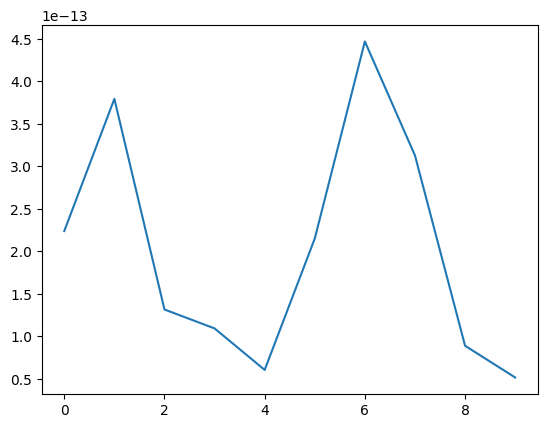

In [59]:
plt.plot(np.abs(eigenvalues_sorted - eigenvalues_nk_sorted)[:N])

In [ ]:
m_Yb = 1


# q = 1.
delta = 4.
omega_R = 3.5

q = 0.
# delta = 0.
# omega_R = 0.


# gamma = 0.2
gamma = 0.0


system = YbSOC2bodyLoss(
    d=jnp.pi / 3,
    lengths=[12],
    n_particle=4,
    hbar=1.,
    q=q,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)